In [ ]:
# ! pip install pytorch-lightning

In [ ]:
# ! pip install torchview

#Data loading and preprocessing

In [ ]:
# import torch
# import torchvision
# from torchvision import transforms
# from torch.utils.data import DataLoader, random_split
# import pytorch_lightning as pl
# import os
# import torch.nn as nn
# import torch.optim as optim
# import torchmetrics
# from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sn
# import pandas as pd
# from sklearn.metrics import classification_report
# import kagglehub

# print("Downloading Kaggle dataset...")
# path = kagglehub.dataset_download("yudhaislamisulistya/plants-type-datasets")
# print(f"Dataset downloaded to: {path}")

# data_dir = os.path.join(path, 'split_ttv_dataset_type_of_plants')
# train_dir = os.path.join(data_dir, 'Train_Set_Folder')
# val_dir = os.path.join(data_dir, 'Validation_Set_Folder')
# test_dir = os.path.join(data_dir, 'Test_Set_Folder')

# # Check if directories exist
# if not os.path.exists(train_dir):
#     print(f"Error: Training directory not found at {train_dir}")
# else:
#     print("Dataset paths verified.")

# # Define image size and batch size
# IMG_SIZE = 128
# BATCH_SIZE = 64

# # Define transforms
# imagenet_mean = [0.485, 0.456, 0.406]
# imagenet_std = [0.229, 0.224, 0.225]

# # Training transforms with augmentation
# train_transform = transforms.Compose([
#     transforms.RandomResizedCrop(IMG_SIZE),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(10),
#     transforms.ToTensor(),
#     transforms.Normalize(imagenet_mean, imagenet_std)
# ])

# # Validation and test transforms
# val_test_transform = transforms.Compose([
#     transforms.Resize(IMG_SIZE),
#     transforms.CenterCrop(IMG_SIZE),
#     transforms.ToTensor(),
#     transforms.Normalize(imagenet_mean, imagenet_std)
# ])

# # Create datasets using ImageFolder
# train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=train_transform)
# val_dataset = torchvision.datasets.ImageFolder(val_dir, transform=val_test_transform)
# test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=val_test_transform)

# #Create DataLoaders
# train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
# val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=2)
# test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=2)

# #Get class info
# class_names = train_dataset.classes
# num_classes = len(class_names)

# print(f"Data loaded.")
# print(f"Number of classes: {num_classes}")
# print(f"Training data size: {len(train_dataset)}")
# print(f"Validation data size: {len(val_dataset)}")
# print(f"Test data size: {len(test_dataset)}")

#Defining the CNN

In [ ]:
# class SimpleCNN(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()
#         # First convolutional layer
#         self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # 3 input channels
#         self.relu1 = nn.ReLU()
#         self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2) #128x128 -> 64x64

#         # Second convolutional layer
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
#         self.relu2 = nn.ReLU()
#         self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2) #64x64 -> 32x32

#         # Third convolutional layer
#         self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
#         self.relu3 = nn.ReLU()
#         self.maxpool3 = nn.MaxPool2d(kernel_size=2, stride=2) #32x32 -> 16x16

#         # Adaptive pooling layer
#         self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))#output fixed size (128 channels, 7x7 spatial)

#         # Fully connected layers
#         self.fc1 = nn.Linear(128 * 7 * 7, 512)
#         self.relu4 = nn.ReLU()
#         self.fc2 = nn.Linear(512, num_classes)

#     def forward(self, x):
#         x = self.conv1(x)
#         x = self.relu1(x)
#         x = self.maxpool1(x)

#         x = self.conv2(x)
#         x = self.relu2(x)
#         x = self.maxpool2(x)

#         x = self.conv3(x)
#         x = self.relu3(x)
#         x = self.maxpool3(x)

#         #adaptive pooling
#         x = self.adaptive_pool(x)

#         # Flatten
#         x = torch.flatten(x, 1)

#         #fully connected layers
#         x = self.fc1(x)
#         x = self.relu4(x)
#         x = self.fc2(x)

#         return x

# #Instantiate
# simple_cnn_model = SimpleCNN(num_classes=num_classes)
# print("Simple CNN Model defined:")
# print(simple_cnn_model)

##Lightning module for **SimpleCNN**

In [ ]:
# class PlantLightningModule(pl.LightningModule):
#     def __init__(self, num_classes, learning_rate=0.001):
#         super().__init__()
#         self.save_hyperparameters()
#         self.model = SimpleCNN(num_classes)
#         self.criterion = nn.CrossEntropyLoss()

#         task = "multiclass"
#         self.train_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
#         self.val_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
#         self.test_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)

#         self.test_precision = torchmetrics.Precision(task=task, num_classes=num_classes, average='macro')
#         self.test_recall = torchmetrics.Recall(task=task, num_classes=num_classes, average='macro')
#         self.test_f1 = torchmetrics.F1Score(task=task, num_classes=num_classes, average='macro')

#         # For confusion matrix
#         self.test_confmat = torchmetrics.ConfusionMatrix(task=task, num_classes=num_classes)
#         self.test_preds = []
#         self.test_labels = []


#     def forward(self, x):
#         return self.model(x)

#     def training_step(self, batch, batch_idx):
#         images, labels = batch
#         outputs = self.model(images)
#         loss = self.criterion(outputs, labels)

#         # Log training loss and accuracy
#         self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
#         self.log('train_acc', self.train_acc(outputs, labels), on_step=True, on_epoch=True, prog_bar=True)
#         return loss

#     def validation_step(self, batch, batch_idx):
#         images, labels = batch
#         outputs = self.model(images)
#         loss = self.criterion(outputs, labels)

#         # Log validation loss and accuracy
#         self.log('val_loss', loss, on_epoch=True, prog_bar=True)
#         self.log('val_acc', self.val_acc(outputs, labels), on_epoch=True, prog_bar=True)
#         return loss

#     def test_step(self, batch, batch_idx):
#         images, labels = batch
#         outputs = self.model(images)
#         loss = self.criterion(outputs, labels)
#         preds = torch.argmax(outputs, dim=1)

#         # Log test loss and accuracy
#         self.log('test_loss', loss, on_epoch=True)
#         self.log('test_acc', self.test_acc(outputs, labels), on_epoch=True)

#         # Log other metrics
#         self.log('test_precision', self.test_precision(preds, labels), on_epoch=True)
#         self.log('test_recall', self.test_recall(preds, labels), on_epoch=True)
#         self.log('test_f1', self.test_f1(preds, labels), on_epoch=True)

#         # Update confusion matrix
#         self.test_confmat.update(preds, labels)
#         # Store preds and labels for classification report
#         self.test_preds.append(preds.cpu())
#         self.test_labels.append(labels.cpu())


#     def configure_optimizers(self):
#         optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
#         return optimizer

# # Instantiate the Lightning Module
# plant_model = PlantLightningModule(num_classes=num_classes, learning_rate=0.001)

# print("Plant Lightning Module defined.")

##Train test and callbacks

In [ ]:
# # --- Callbacks ---
# # Model Checkpoint
# checkpoint_callback = ModelCheckpoint(
#     monitor='val_acc',
#     mode='max',
#     dirpath='checkpoints_plant_simple/',
#     filename='best-plant-cnn-model',
#     save_top_k=1,
#     verbose=True
# )

# # Early Stopping
# early_stopping_callback = EarlyStopping(
#     monitor='val_loss',
#     mode='min',
#     patience=5, #stop if val_loss doesn t improve for 5 epochs
#     verbose=True
# )

# # Learning Rate Monitor
# lr_monitor_callback = LearningRateMonitor(logging_interval='epoch')

# # --- Trainer ---
# trainer = pl.Trainer(
#     max_epochs=20,
#     accelerator='auto',
#     callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback]
# )

# # --- Start Training ---
# print("Starting plant model training...")
# trainer.fit(plant_model, train_dataloader, val_dataloader)

# # --- Start Testing ---
# print("\nStarting plant model testing...")
# test_results = trainer.test(plant_model, test_dataloader)
# print("Test Results:", test_results)

##Evaluation for SimpleCNN

In [ ]:
# print("\n--- Detailed Evaluation ---")

# #Classification Report
# all_preds = torch.cat(plant_model.test_preds)
# all_labels = torch.cat(plant_model.test_labels)

# report = classification_report(
#     all_labels.numpy(),
#     all_preds.numpy(),
#     target_names=class_names,
#     digits=3
# )
# print("Classification Report:")
# print(report)


# #Confusion Matrix
# confmat = plant_model.test_confmat.compute().cpu().numpy()
# df_cm = pd.DataFrame(
#     confmat,
#     index=[name for name in class_names],
#     columns=[name for name in class_names]
# )

# plt.figure(figsize=(20, 15))
# sn.heatmap(df_cm, annot=True, fmt='g', cmap='Blues')
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix")
# plt.show()

#Resnet50 frozen

In [ ]:
# import torchvision.models as models

# class PretrainedResNet(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()


#         self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)


#         for param in self.model.parameters():
#             param.requires_grad = False

#         num_features = self.model.fc.in_features
#         self.model.fc = nn.Linear(num_features, num_classes)


#     def forward(self, x):
#         return self.model(x)

# # --- Instantiate the model ---
# pretrained_model = PretrainedResNet(num_classes=num_classes)
# print(f"Loaded pretrained ResNet-50.")

##Lightning for Resnet

In [ ]:
# class PretrainedLightningModule(pl.LightningModule):
#     def __init__(self, num_classes, learning_rate=0.001):
#         super().__init__()
#         self.save_hyperparameters()

#         self.model = PretrainedResNet(num_classes)

#         self.criterion = nn.CrossEntropyLoss()

#         task = "multiclass"
#         self.train_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
#         self.val_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
#         self.test_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
#         self.test_precision = torchmetrics.Precision(task=task, num_classes=num_classes, average='macro')
#         self.test_recall = torchmetrics.Recall(task=task, num_classes=num_classes, average='macro')
#         self.test_f1 = torchmetrics.F1Score(task=task, num_classes=num_classes, average='macro')
#         self.test_confmat = torchmetrics.ConfusionMatrix(task=task, num_classes=num_classes)
#         self.test_preds = []
#         self.test_labels = []

#     def forward(self, x):
#         return self.model(x)

#     def training_step(self, batch, batch_idx):
#         images, labels = batch
#         outputs = self.model(images)
#         loss = self.criterion(outputs, labels)
#         self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
#         self.log('train_acc', self.train_acc(outputs, labels), on_step=True, on_epoch=True, prog_bar=True)
#         return loss

#     def validation_step(self, batch, batch_idx):
#         images, labels = batch
#         outputs = self.model(images)
#         loss = self.criterion(outputs, labels)
#         self.log('val_loss', loss, on_epoch=True, prog_bar=True)
#         self.log('val_acc', self.val_acc(outputs, labels), on_epoch=True, prog_bar=True)
#         return loss

#     def test_step(self, batch, batch_idx):
#         images, labels = batch
#         outputs = self.model(images)
#         loss = self.criterion(outputs, labels)
#         preds = torch.argmax(outputs, dim=1)

#         self.log('test_loss', loss, on_epoch=True)
#         self.log('test_acc', self.test_acc(outputs, labels), on_epoch=True)
#         self.log('test_precision', self.test_precision(preds, labels), on_epoch=True)
#         self.log('test_recall', self.test_recall(preds, labels), on_epoch=True)
#         self.log('test_f1', self.test_f1(preds, labels), on_epoch=True)

#         self.test_confmat.update(preds, labels)
#         self.test_preds.append(preds.cpu())
#         self.test_labels.append(labels.cpu())

#     def configure_optimizers(self):

#         optimizer = optim.Adam(self.model.model.fc.parameters(), lr=self.hparams.learning_rate)
#         return optimizer

# #Instantiate the Lightning Module
# pretrained_lightning_model = PretrainedLightningModule(num_classes=num_classes, learning_rate=0.001)

##Train test

In [ ]:

# checkpoint_callback_resnet = ModelCheckpoint(
#     monitor='val_acc',
#     mode='max',
#     dirpath='checkpoints_plant_resnet/',
#     filename='best-plant-resnet-model',
#     save_top_k=1,
#     verbose=True
# )

# early_stopping_callback_resnet = EarlyStopping(
#     monitor='val_loss',
#     mode='min',
#     patience=5,
#     verbose=True
# )

# lr_monitor_callback_resnet = LearningRateMonitor(logging_interval='epoch')

# trainer_resnet = pl.Trainer(
#     max_epochs=15,
#     accelerator='auto',
#     callbacks=[checkpoint_callback_resnet, early_stopping_callback_resnet, lr_monitor_callback_resnet]
# )

# #Start Training
# print("Starting ResNet model training...")
# trainer_resnet.fit(pretrained_lightning_model, train_dataloader, val_dataloader)

# #Start Testing
# print("\nStarting ResNet model testing...")
# test_results_resnet = trainer_resnet.test(pretrained_lightning_model, test_dataloader)
# print("ResNet Test Results:", test_results_resnet)

##Evaluate resnet

In [ ]:
# import seaborn as sn
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.metrics import classification_report

# print("\n--- Detailed ResNet Evaluation ---")

# all_preds = torch.cat(pretrained_lightning_model.test_preds)
# all_labels = torch.cat(pretrained_lightning_model.test_labels)

# report = classification_report(
#     all_labels.numpy(),        # True labels
#     all_preds.numpy(),         # Predicted labels
#     target_names=class_names,  # The list of class names from Step 1
#     digits=3
# )
# print("Classification Report:")
# print(report)


# confmat = pretrained_lightning_model.test_confmat.compute().cpu().numpy()

# # Create a pandas DataFrame for better labeling
# df_cm = pd.DataFrame(
#     confmat,
#     index=[name for name in class_names],
#     columns=[name for name in class_names]
# )

# # Plot the heatmap
# plt.figure(figsize=(20, 15))
# sn.heatmap(df_cm, annot=True, fmt='g', cmap='Blues')
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("ResNet-50 Confusion Matrix")
# plt.show()

In [ ]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import pytorch_lightning as pl
import os
import torch.nn as nn
import torch.optim as optim
import torchmetrics
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from sklearn.metrics import classification_report
import kagglehub
import torchvision.models as models



print("Downloading Kaggle dataset...")
# Download the dataset
path = kagglehub.dataset_download("yudhaislamisulistya/plants-type-datasets")
print(f"Dataset downloaded to: {path}")

# --- 1. DATA PREPARATION ---

# Define paths
data_dir = os.path.join(path, 'split_ttv_dataset_type_of_plants')
train_dir = os.path.join(data_dir, 'Train_Set_Folder')
val_dir = os.path.join(data_dir, 'Validation_Set_Folder')
test_dir = os.path.join(data_dir, 'Test_Set_Folder')

# Check if directories exist
if not os.path.exists(train_dir):
    print(f"Error: Training directory not found at {train_dir}")
else:
    print("Dataset paths verified.")

# Define image size and batch size
IMG_SIZE = 128
BATCH_SIZE = 64

# Define transforms
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Validation and test transforms
val_test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Create datasets using ImageFolder
train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = torchvision.datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=val_test_transform)

#Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=2)

#Get class info
class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Data loaded.")
print(f"Number of classes: {num_classes}")
print(f"Training data size: {len(train_dataset)}")
print(f"Validation data size: {len(val_dataset)}")
print(f"Test data size: {len(test_dataset)}")




Using Colab cache for faster access to the 'plants-type-datasets' dataset.
Dataset downloaded to: /kaggle/input/plants-type-datasets
Dataset paths verified.
Data loaded.
Number of classes: 30
Training data size: 23972
Validation data size: 3030
Test data size: 2998


#Resnet 18

In [ ]:
class FineTuneResNet18(nn.Module):
    """
    A ResNet-18 model for fine-tuning.
    We load the pre-trained weights but do NOT freeze any layers.
    """
    def __init__(self, num_classes):
        super().__init__()

        # Load pre-trained ResNet-18
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Replace the final fully connected layer
        num_features = self.model.fc.in_features
        self.model.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.model(x)
# --- Instantiate the model ---
finetune_model = FineTuneResNet18(num_classes=num_classes)
print(f"\nLoaded pre-trained ResNet-18 for fine-tuning.")



Loaded pre-trained ResNet-18 for fine-tuning.


##Lightning

In [ ]:
class FineTuneLightningModule(pl.LightningModule):
    """
    PyTorch Lightning Module for fine-tuning the ResNet-18 model.
    """
    def __init__(self, num_classes, learning_rate=1e-4): # Lower LR for fine-tuning
        super().__init__()
        self.save_hyperparameters()

        # Use the new FineTuneResNet18 model
        self.model = FineTuneResNet18(num_classes)
        self.criterion = nn.CrossEntropyLoss()

        # Metrics
        task = "multiclass"
        self.train_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
        self.test_precision = torchmetrics.Precision(task=task, num_classes=num_classes, average='macro')
        self.test_recall = torchmetrics.Recall(task=task, num_classes=num_classes, average='macro')
        self.test_f1 = torchmetrics.F1Score(task=task, num_classes=num_classes, average='macro')
        self.test_confmat = torchmetrics.ConfusionMatrix(task=task, num_classes=num_classes)

        # For evaluation
        self.test_preds = []
        self.test_labels = []

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_acc(outputs, labels), on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_acc(outputs, labels), on_epoch=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1)

        # Log metrics
        self.log('test_loss', loss, on_epoch=True)
        self.log('test_acc', self.test_acc(outputs, labels), on_epoch=True)
        self.log('test_precision', self.test_precision(preds, labels), on_epoch=True)
        self.log('test_recall', self.test_recall(preds, labels), on_epoch=True)
        self.log('test_f1', self.test_f1(preds, labels), on_epoch=True)

        # Save preds and labels for confusion matrix
        self.test_confmat.update(preds, labels)
        self.test_preds.append(preds.cpu())
        self.test_labels.append(labels.cpu())

    def configure_optimizers(self):
        # **KEY DIFFERENCE**: Pass all parameters to the optimizer
        optimizer = optim.Adam(self.model.parameters(), lr=self.hparams.learning_rate)

        # Add a learning rate scheduler (good practice for fine-tuning)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.1,
            patience=3,

        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss", # Monitor validation loss
                "interval": "epoch",
                "frequency": 1
            }
        }


##Train test

In [ ]:
# Instantiate the Lightning Module
finetune_lightning_model = FineTuneLightningModule(num_classes=num_classes, learning_rate=1e-4)

# Define new callbacks
checkpoint_callback_finetune = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    dirpath='checkpoints_plant_finetune/', # New directory
    filename='best-plant-finetune-model',  # New filename
    save_top_k=1,
    verbose=True
)

early_stopping_callback_finetune = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5, # Stop if val_loss doesn't improve for 5 epochs
    verbose=True
)

lr_monitor_callback_finetune = LearningRateMonitor(logging_interval='epoch')

# Define a new trainer
trainer_finetune = pl.Trainer(
    max_epochs=20, # You might want to train for longer than the frozen model
    accelerator='auto',
    callbacks=[
        checkpoint_callback_finetune,
        early_stopping_callback_finetune,
        lr_monitor_callback_finetune
    ]
)

# Start Training
print("Starting ResNet-18 (Fine-Tune) model training...")
trainer_finetune.fit(finetune_lightning_model, train_dataloader, val_dataloader)

# Start Testing
print("\nStarting ResNet-18 (Fine-Tune) model testing...")
# Load the best checkpoint for testing
test_results_finetune = trainer_finetune.test(
    finetune_lightning_model,
    test_dataloader,
    ckpt_path='best' # Automatically uses the best checkpoint
)
print("ResNet-18 (Fine-Tune) Test Results:", test_results_finetune)



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name           | Type                      | Params | Mode 
---------------------------------------------------------------------
0 | model          | FineTuneResNet18          | 11.2 M | train
1 | criterion      | CrossEntropyLoss          | 0      | train
2 | train_acc      | MulticlassAccuracy        | 0      | train
3 | val_acc        | MulticlassAccuracy        | 0      | train
4 | test_acc       | MulticlassAccuracy        | 0      | train
5 | test_precision | MulticlassPrecision       | 0      | train
6 | test_recall    | MulticlassRecall          | 0      | train
7 | test_f1        | MulticlassF1Score         | 0      | train
8 | test_confmat   | MulticlassConfusionMatrix | 0      |

Starting ResNet-18 (Fine-Tune) model training...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.008 >= min_delta = 0.0. New best score: 0.046
INFO:pytorch_lightning.utilities.rank_zero:Epoch 19, global step 7500: 'val_acc' reached 0.98680 (best 0.98680), saving model to '/content/checkpoints_plant_finetune/best-plant-finetune-model.ckpt' as top 1
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints_plant_finetune/best-plant-finetune-model.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints_plant_finetune/best-plant-finetune-model.ckpt



Starting ResNet-18 (Fine-Tune) model testing...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9806537628173828     │
│          test_f1          │    0.7343403100967407     │
│         test_loss         │    0.04912715405225754    │
│      test_precision       │    0.7387689352035522     │
│        test_recall        │     0.730368971824646     │
└───────────────────────────┴───────────────────────────┘

ResNet-18 (Fine-Tune) Test Results: [{'test_loss': 0.04912715405225754, 'test_acc': 0.9806537628173828, 'test_precision': 0.7387689352035522, 'test_recall': 0.730368971824646, 'test_f1': 0.7343403100967407}]


##Eval


--- Detailed ResNet-18 (Fine-Tune) Evaluation ---
Classification Report:
                precision    recall  f1-score   support

      aloevera      1.000     0.970     0.985       100
        banana      0.980     1.000     0.990       100
       bilimbi      0.990     0.980     0.985       100
    cantaloupe      0.869     0.930     0.899       100
       cassava      0.990     1.000     0.995       100
       coconut      0.980     0.970     0.975       100
          corn      0.990     1.000     0.995       100
      cucumber      0.990     1.000     0.995        99
       curcuma      0.980     0.960     0.970       100
      eggplant      1.000     0.990     0.995       100
      galangal      0.980     1.000     0.990       100
        ginger      0.970     0.980     0.975       100
         guava      0.990     1.000     0.995       100
          kale      0.971     1.000     0.985       100
     longbeans      0.980     0.980     0.980       100
         mango      0.990    

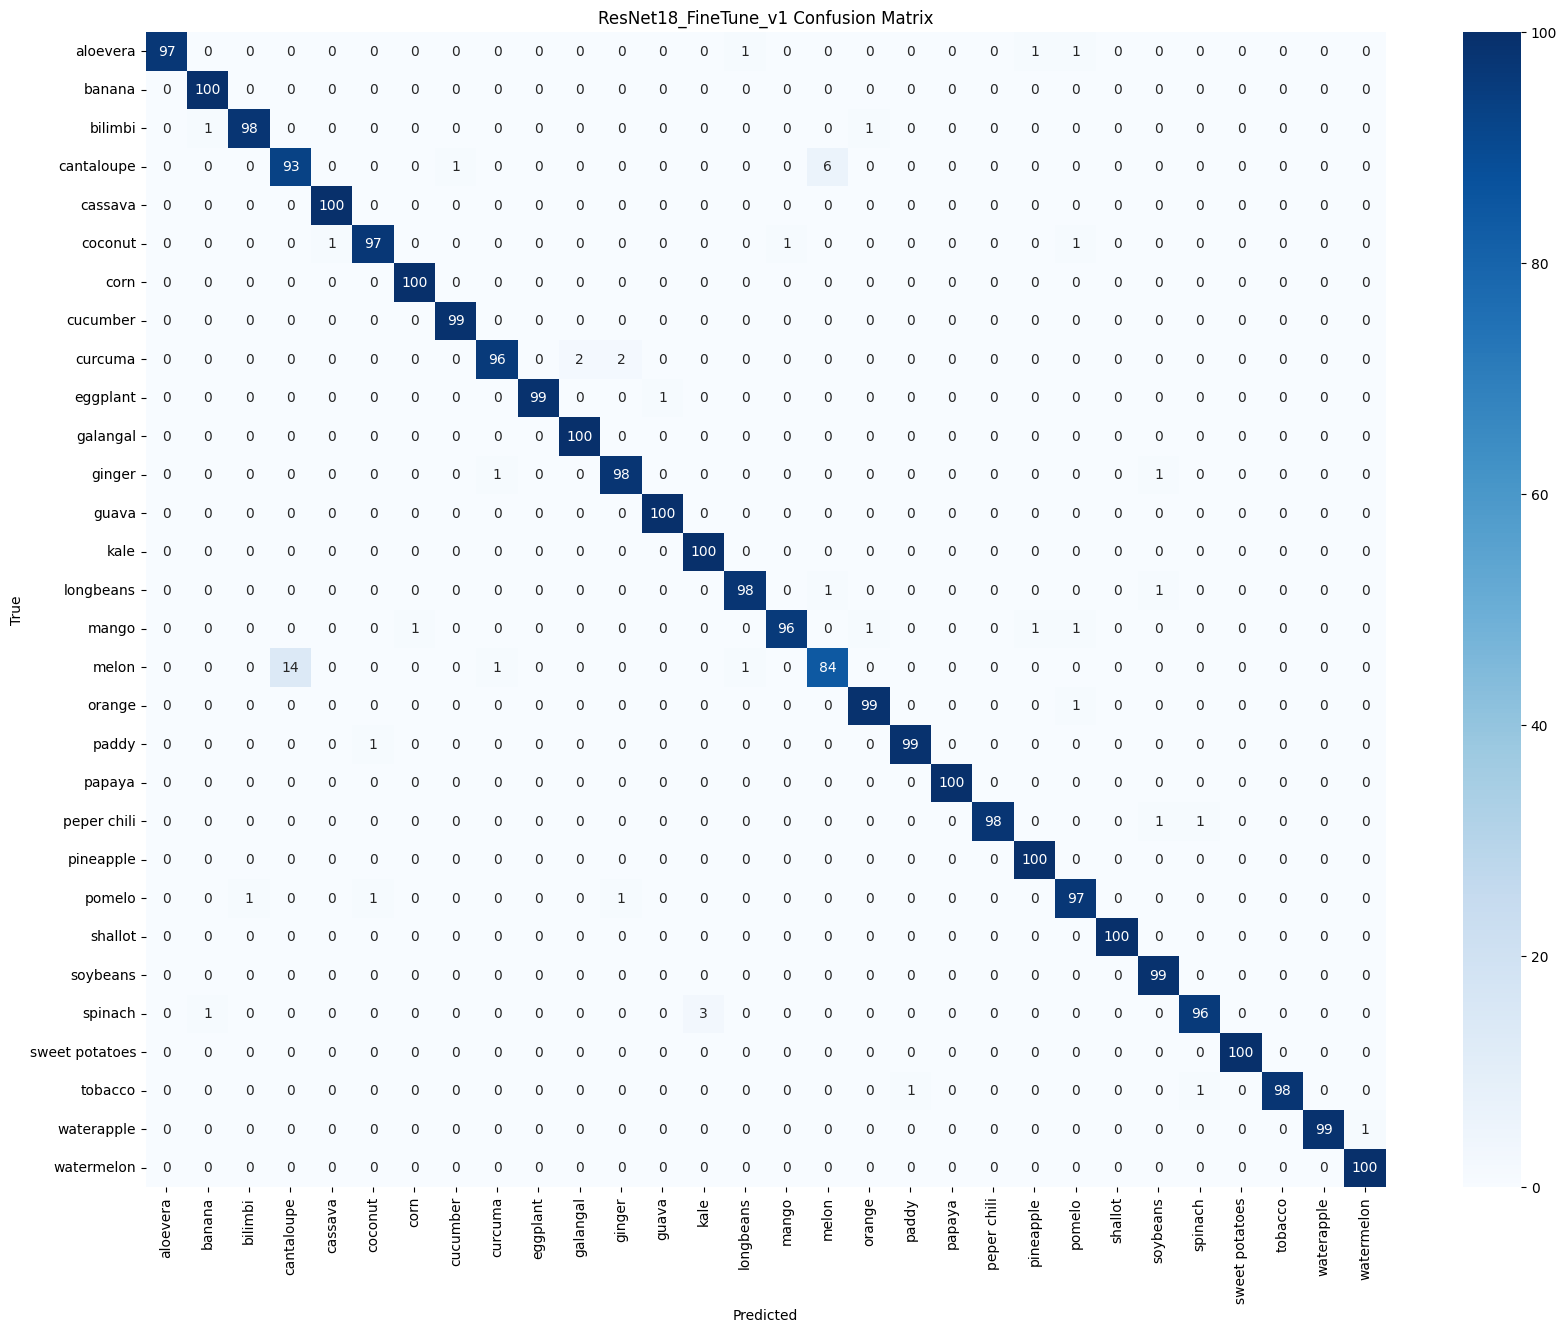

In [ ]:
import json

print("\n--- Detailed ResNet-18 (Fine-Tune) Evaluation ---")

# Get the main test results from the trainer
# test_results_finetune is a list containing a dict, e.g., [{'test_loss': ..., 'test_acc': ...}]
overall_metrics = test_results_finetune[0]
model_name = "ResNet18_FineTune_v1" # Give this model a unique name

# Get all predictions and labels
all_preds = torch.cat(finetune_lightning_model.test_preds)
all_labels = torch.cat(finetune_lightning_model.test_labels)

# --- Classification Report ---
# Get string report for printing
report_str = classification_report(
    all_labels.numpy(),      # True labels
    all_preds.numpy(),       # Predicted labels
    target_names=class_names, # The list of class names
    digits=3
)
print("Classification Report:")
print(report_str)

# --- Get dictionary report for saving ---
report_dict = classification_report(
    all_labels.numpy(),
    all_preds.numpy(),
    target_names=class_names,
    output_dict=True
)

#Confusion Matrix
confmat = finetune_lightning_model.test_confmat.compute().cpu().numpy()
df_cm = pd.DataFrame(
    confmat,
    index=[name for name in class_names],
    columns=[name for name in class_names]
)

plt.figure(figsize=(20, 15))
sn.heatmap(df_cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"{model_name} Confusion Matrix") # Use the model name in title
plt.savefig(f"{model_name}_confusion_matrix.png") # Use model name in filename
print(f"Confusion matrix plot saved to {model_name}_confusion_matrix.png")


#SAVE RESULTS FOR COMPARISON

print(f"\n💾 Saving results for model: {model_name}...")

# Combine all results into one dictionary for this model
final_model_results = {
    "overall_metrics": overall_metrics,
    "classification_report": report_dict
}

# Define the file to store all model comparisons
results_file = "model_comparison_results.json"

# Load existing results if the file exists, or create a new dict
try:
    with open(results_file, 'r') as f:
        all_model_results = json.load(f)
except FileNotFoundError:
    all_model_results = {}

# Add or update the results for the current model
all_model_results[model_name] = final_model_results

# Save the updated results back to the file
with open(results_file, 'w') as f:
    json.dump(all_model_results, f, indent=4)

print(f"✅ Results successfully saved to {results_file}")
print(f"You can now run another model (e.g., 'ResNet34') and its results will be added to this file.")

#EfficientNet

In [ ]:
class FineTuneEfficientNetB0(nn.Module):
    """
    An EfficientNet-B0 model for fine-tuning.
    We load the pre-trained weights and replace the final classifier.
    """
    def __init__(self, num_classes):
        super().__init__()

        # 1. Load pre-trained EfficientNet-B0
        self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)


        num_features = self.model.classifier[1].in_features

        # Replace the Linear layer
        self.model.classifier[1] = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.model(x)

print(f"\nDefined FineTuneEfficientNetB0 model class.")


Defined FineTuneEfficientNetB0 model class.


##Lightning

In [ ]:
class FineTuneLightningModule(pl.LightningModule):
    """
    PyTorch Lightning Module for fine-tuning.
    This module is now generic and accepts a model class.
    """
    def __init__(self, model_class, num_classes, learning_rate=1e-4):
        super().__init__()
        # Save hyperparameters
        self.save_hyperparameters('num_classes', 'learning_rate')

        # Instantiate the model from the passed class
        self.model = model_class(num_classes)
        self.criterion = nn.CrossEntropyLoss()

        # Metrics
        task = "multiclass"
        self.train_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
        self.test_precision = torchmetrics.Precision(task=task, num_classes=num_classes, average='macro')
        self.test_recall = torchmetrics.Recall(task=task, num_classes=num_classes, average='macro')
        self.test_f1 = torchmetrics.F1Score(task=task, num_classes=num_classes, average='macro')
        self.test_confmat = torchmetrics.ConfusionMatrix(task=task, num_classes=num_classes)

        # For evaluation
        self.test_preds = []
        self.test_labels = []

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_acc(outputs, labels), on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_acc(outputs, labels), on_epoch=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1)

        # Log metrics
        self.log('test_loss', loss, on_epoch=True)
        self.log('test_acc', self.test_acc(outputs, labels), on_epoch=True)
        self.log('test_precision', self.test_precision(preds, labels), on_epoch=True)
        self.log('test_recall', self.test_recall(preds, labels), on_epoch=True)
        self.log('test_f1', self.test_f1(preds, labels), on_epoch=True)

        # Save preds and labels for confusion matrix
        self.test_confmat.update(preds, labels)
        self.test_preds.append(preds.cpu())
        self.test_labels.append(labels.cpu())

    def configure_optimizers(self):
        optimizer = optim.Adam(self.model.parameters(), lr=self.hparams.learning_rate)

        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.1,
            patience=3,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1
            }
        }

##Train-Test

In [ ]:
# --- Define experiment settings ---
MODEL_NAME = "EfficientNet_B0_v1"
MODEL_CLASS = FineTuneEfficientNetB0 # Use the new class
LEARNING_RATE = 1e-4 # 1e-4 is a good start. You can also try 5e-4 or 1e-3.

# Instantiate the Lightning Module
finetune_lightning_model = FineTuneLightningModule(
    model_class=MODEL_CLASS,
    num_classes=num_classes,
    learning_rate=LEARNING_RATE
)

# Define new callbacks
checkpoint_callback_finetune = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    dirpath=f'checkpoints_{MODEL_NAME}/', # New directory
    filename=f'best-{MODEL_NAME}-model',  # New filename
    save_top_k=1,
    verbose=True
)

early_stopping_callback_finetune = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    verbose=True
)

lr_monitor_callback_finetune = LearningRateMonitor(logging_interval='epoch')

# Define a new trainer
trainer_finetune = pl.Trainer(
    max_epochs=20,
    accelerator='auto',
    callbacks=[
        checkpoint_callback_finetune,
        early_stopping_callback_finetune,
        lr_monitor_callback_finetune
    ]
)

# Start Training
print(f"Starting {MODEL_NAME} model training...")
trainer_finetune.fit(finetune_lightning_model, train_dataloader, val_dataloader)

# Start Testing
print(f"\nStarting {MODEL_NAME} model testing...")
# Load the best checkpoint for testing
test_results_finetune = trainer_finetune.test(
    finetune_lightning_model,
    test_dataloader,
    ckpt_path='best' # Automatically uses the best checkpoint
)
print(f"{MODEL_NAME} Test Results:", test_results_finetune)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 167MB/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name           | Type                      | Params | Mode 
---------------------------------------------------------------------
0 | model          | FineTuneEfficientNetB0    | 4.0 M  | train
1 | criterion      | CrossEntropyLoss          | 0      | train
2 | train_acc      | MulticlassAccuracy        | 0      | train
3 | val_acc        | MulticlassAccuracy        | 0      | train
4 | test_acc       | MulticlassAccuracy        | 0      | train
5 | test_precision | MulticlassPrecision       | 0      | train
6 | test_recall    | MulticlassRecall          | 0      | train
7 | test_f1        | MulticlassF1Score         | 0      | train
8 | t

Starting EfficientNet_B0_v1 model training...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:Epoch 19, global step 7500: 'val_acc' was not in top 1
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints_EfficientNet_B0_v1/best-EfficientNet_B0_v1-model.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints_EfficientNet_B0_v1/best-EfficientNet_B0_v1-model.ckpt



Starting EfficientNet_B0_v1 model testing...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9916611313819885     │
│          test_f1          │    0.8979594707489014     │
│         test_loss         │    0.02274763025343418    │
│      test_precision       │    0.9003779888153076     │
│        test_recall        │    0.8958231210708618     │
└───────────────────────────┴───────────────────────────┘

EfficientNet_B0_v1 Test Results: [{'test_loss': 0.02274763025343418, 'test_acc': 0.9916611313819885, 'test_precision': 0.9003779888153076, 'test_recall': 0.8958231210708618, 'test_f1': 0.8979594707489014}]


##Eval


--- Detailed EfficientNet_B0_v1 Evaluation ---
Classification Report:
                precision    recall  f1-score   support

      aloevera      1.000     1.000     1.000       100
        banana      0.990     1.000     0.995       100
       bilimbi      1.000     1.000     1.000       100
    cantaloupe      0.868     0.990     0.925       100
       cassava      1.000     1.000     1.000       100
       coconut      1.000     1.000     1.000       100
          corn      1.000     1.000     1.000       100
      cucumber      1.000     1.000     1.000        99
       curcuma      0.990     1.000     0.995       100
      eggplant      1.000     1.000     1.000       100
      galangal      1.000     0.990     0.995       100
        ginger      1.000     0.990     0.995       100
         guava      1.000     1.000     1.000       100
          kale      0.980     1.000     0.990       100
     longbeans      1.000     1.000     1.000       100
         mango      1.000     0.

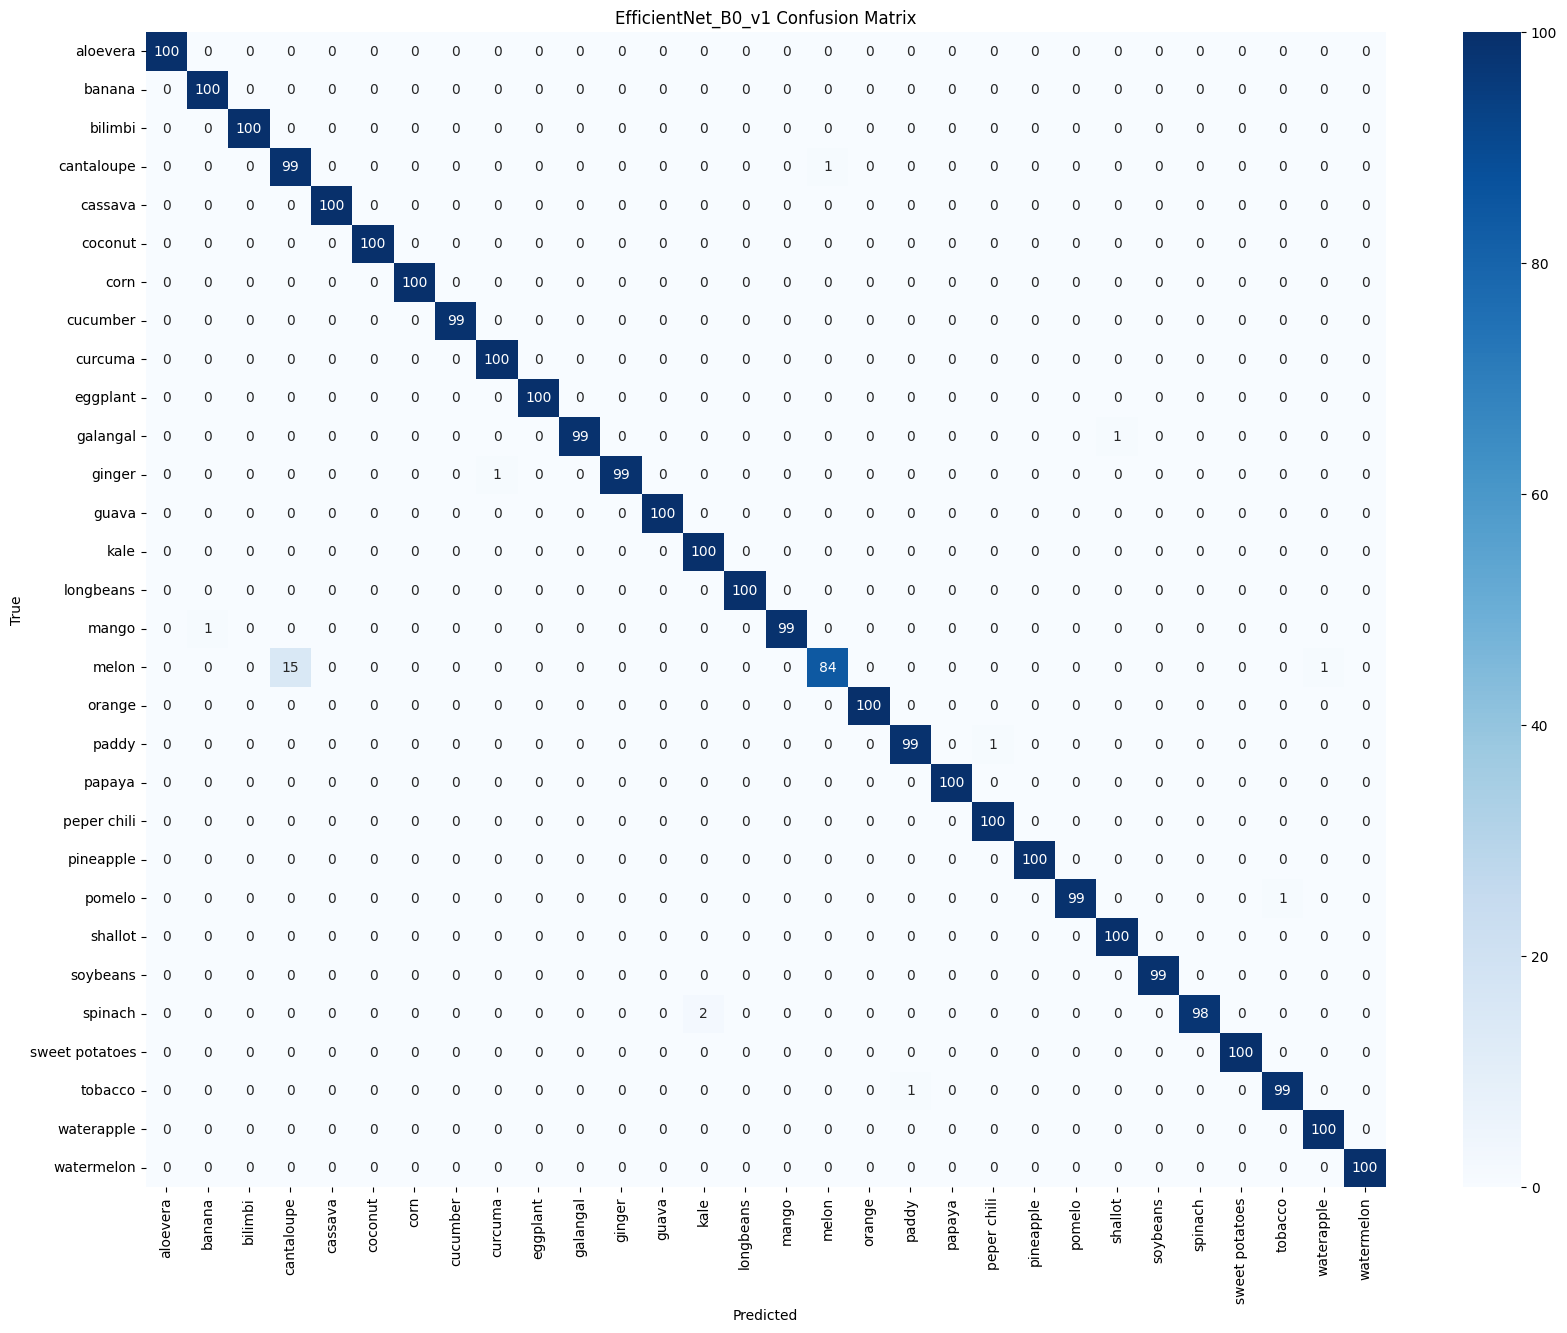

In [ ]:
# --- 5. EVALUATION ---

model_name = "EfficientNet_B0_v1" # Set the model name for this evaluation

print(f"\n--- Detailed {model_name} Evaluation ---")

# Get the main test results from the trainer
overall_metrics = test_results_finetune[0]

# Get all predictions and labels
all_preds = torch.cat(finetune_lightning_model.test_preds)
all_labels = torch.cat(finetune_lightning_model.test_labels)

# --- Classification Report ---
# Get string report for printing
report_str = classification_report(
    all_labels.numpy(),
    all_preds.numpy(),
    target_names=class_names,
    digits=3
)
print("Classification Report:")
print(report_str)

# --- Get dictionary report for saving ---
report_dict = classification_report(
    all_labels.numpy(),
    all_preds.numpy(),
    target_names=class_names,
    output_dict=True
)

# --- Confusion Matrix ---
confmat = finetune_lightning_model.test_confmat.compute().cpu().numpy()
df_cm = pd.DataFrame(
    confmat,
    index=[name for name in class_names],
    columns=[name for name in class_names]
)

plt.figure(figsize=(20, 15))
sn.heatmap(df_cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"{model_name} Confusion Matrix") # Use the model name in title
plt.savefig(f"{model_name}_confusion_matrix.png") # Use model name in filename
print(f"Confusion matrix plot saved to {model_name}_confusion_matrix.png")


# --- 6. SAVE RESULTS FOR COMPARISON ---

print(f"\n💾 Saving results for model: {model_name}...")

# Combine all results into one dictionary for this model
final_model_results = {
    "overall_metrics": overall_metrics,
    "classification_report": report_dict
}

# Define the file to store all model comparisons
results_file = "model_comparison_results.json"

# Load existing results if the file exists, or create a new dict
try:
    with open(results_file, 'r') as f:
        all_model_results = json.load(f)
except FileNotFoundError:
    all_model_results = {}

# Add or update the results for the current model
all_model_results[model_name] = final_model_results

# Save the updated results back to the file
with open(results_file, 'w') as f:
    json.dump(all_model_results, f, indent=4)

print(f"✅ Results successfully saved to {results_file}")

#Vit

In [ ]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import pytorch_lightning as pl
import os
import torch.nn as nn
import torch.optim as optim
import torchmetrics
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from sklearn.metrics import classification_report
import kagglehub
import torchvision.models as models
import json # Make sure this is imported

print("Downloading Kaggle dataset...")
# Download the dataset
path = kagglehub.dataset_download("yudhaislamisulistya/plants-type-datasets")
print(f"Dataset downloaded to: {path}")

# --- 1. DATA PREPARATION ---

# Define paths
data_dir = os.path.join(path, 'split_ttv_dataset_type_of_plants')
train_dir = os.path.join(data_dir, 'Train_Set_Folder')
val_dir = os.path.join(data_dir, 'Validation_Set_Folder')
test_dir = os.path.join(data_dir, 'Test_Set_Folder')

# Check if directories exist
if not os.path.exists(train_dir):
    print(f"Error: Training directory not found at {train_dir}")
else:
    print("Dataset paths verified.")

# --- CRITICAL CHANGE: ViT requires 224x224 ---
IMG_SIZE = 224
BATCH_SIZE = 64 # You may need to lower this to 32 if you run out of GPU memory

# Define transforms
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE), # Updated to 224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Validation and test transforms
val_test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE), # Updated to 224
    transforms.CenterCrop(IMG_SIZE), # Updated to 224
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Create datasets using ImageFolder
train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = torchvision.datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=val_test_transform)

#Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=2)

#Get class info
class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Data loaded.")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Number of classes: {num_classes}")
print(f"Training data size: {len(train_dataset)}")
print(f"Validation data size: {len(val_dataset)}")
print(f"Test data size: {len(test_dataset)}")

Using Colab cache for faster access to the 'plants-type-datasets' dataset.
Dataset downloaded to: /kaggle/input/plants-type-datasets
Dataset paths verified.
Data loaded.
Image Size: 224x224
Number of classes: 30
Training data size: 23972
Validation data size: 3030
Test data size: 2998


In [ ]:
class FineTuneViT(nn.Module):
    """
    A Vision Transformer (ViT-B-16) model for fine-tuning.
    We load the pre-trained weights and replace the final 'head'.
    """
    def __init__(self, num_classes):
        super().__init__()

        # 1. Load pre-trained ViT-B-16
        self.model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

        # 2. Replace the final classifier
        # The final layer in torchvision's ViT is called 'heads'
        num_features = self.model.heads.head.in_features

        # Replace the head with a new Linear layer
        self.model.heads.head = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.model(x)

print(f"\nDefined FineTuneViT model class.")


Defined FineTuneViT model class.


In [ ]:
class FineTuneLightningModule(pl.LightningModule):
    """
    PyTorch Lightning Module for fine-tuning.
    This module is generic and accepts a model class.
    """
    def __init__(self, model_class, num_classes, learning_rate=1e-4):
        super().__init__()
        # Save hyperparameters
        self.save_hyperparameters('num_classes', 'learning_rate')

        # Instantiate the model from the passed class
        self.model = model_class(num_classes)
        self.criterion = nn.CrossEntropyLoss()

        # Metrics
        task = "multiclass"
        self.train_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
        self.test_precision = torchmetrics.Precision(task=task, num_classes=num_classes, average='macro')
        self.test_recall = torchmetrics.Recall(task=task, num_classes=num_classes, average='macro')
        self.test_f1 = torchmetrics.F1Score(task=task, num_classes=num_classes, average='macro')
        self.test_confmat = torchmetrics.ConfusionMatrix(task=task, num_classes=num_classes)

        # For evaluation
        self.test_preds = []
        self.test_labels = []

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_acc(outputs, labels), on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_acc(outputs, labels), on_epoch=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1)

        # Log metrics
        self.log('test_loss', loss, on_epoch=True)
        self.log('test_acc', self.test_acc(outputs, labels), on_epoch=True)
        self.log('test_precision', self.test_precision(preds, labels), on_epoch=True)
        self.log('test_recall', self.test_recall(preds, labels), on_epoch=True)
        self.log('test_f1', self.test_f1(preds, labels), on_epoch=True)

        # Save preds and labels for confusion matrix
        self.test_confmat.update(preds, labels)
        self.test_preds.append(preds.cpu())
        self.test_labels.append(labels.cpu())

    def configure_optimizers(self):
        optimizer = optim.Adam(self.model.parameters(), lr=self.hparams.learning_rate)

        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.1,
            patience=3,

        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1
            }
        }

In [ ]:
# --- Define experiment settings ---
MODEL_NAME = "ViT_B16_v1"
MODEL_CLASS = FineTuneViT # Use the new ViT class

# --- CRITICAL CHANGE: Use a smaller learning rate for ViT ---
LEARNING_RATE = 1e-5 # 1e-4 is likely too high for ViT

# Instantiate the Lightning Module
finetune_lightning_model = FineTuneLightningModule(
    model_class=MODEL_CLASS,
    num_classes=num_classes,
    learning_rate=LEARNING_RATE
)

# Define new callbacks
checkpoint_callback_finetune = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    dirpath=f'checkpoints_{MODEL_NAME}/', # New directory
    filename=f'best-{MODEL_NAME}-model',  # New filename
    save_top_k=1,
    verbose=True
)

early_stopping_callback_finetune = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    verbose=True
)

lr_monitor_callback_finetune = LearningRateMonitor(logging_interval='epoch')

# Define a new trainer
trainer_finetune = pl.Trainer(
    max_epochs=20,
    accelerator='auto',
    callbacks=[
        checkpoint_callback_finetune,
        early_stopping_callback_finetune,
        lr_monitor_callback_finetune
    ]
)

# Start Training
print(f"Starting {MODEL_NAME} model training...")
trainer_finetune.fit(finetune_lightning_model, train_dataloader, val_dataloader)

# Start Testing
print(f"\nStarting {MODEL_NAME} model testing...")
# Load the best checkpoint for testing
test_results_finetune = trainer_finetune.test(
    finetune_lightning_model,
    test_dataloader,
    ckpt_path='best' # Automatically uses the best checkpoint
)
print(f"{MODEL_NAME} Test Results:", test_results_finetune)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 201MB/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name           | Type                      | Params | Mode 
---------------------------------------------------------------------
0 | model          | FineTuneViT               | 85.8 M | train
1 | criterion      | CrossEntropyLoss          | 0      | train
2 | train_acc      | MulticlassAccuracy        | 0      | train
3 | val_acc        | MulticlassAccuracy        | 0      | train
4 | test_acc       | MulticlassAccuracy        | 0      | train
5 | test_precision | MulticlassPrecision       | 0      | train
6 | test_recall    | MulticlassRecall          | 0      | train
7 | test_f1        | MulticlassF1Score         | 0      | train
8 | tes

Starting ViT_B16_v1 model training...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.003 >= min_delta = 0.0. New best score: 0.018
INFO:pytorch_lightning.utilities.rank_zero:Epoch 17, global step 6750: 'val_acc' reached 0.99472 (best 0.99472), saving model to '/content/checkpoints_ViT_B16_v1/best-ViT_B16_v1-model.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Epoch 18, global step 7125: 'val_acc' was not in top 1
INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 598, in _fit_impl
    self._run(model, ckpt_path=ckpt_path)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1011, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1055, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 216, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 458, in advance
    self.epoch_loop.run(self._data_fetcher)
  File "/usr/local/lib/python3.12

TypeError: object of type 'NoneType' has no len()

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints_ViT_B16_v1/best-ViT_B16_v1-model.ckpt



Starting ViT_B16_v1 model testing...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints_ViT_B16_v1/best-ViT_B16_v1-model.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9926617741584778     │
│          test_f1          │    0.9223763346672058     │
│         test_loss         │    0.02462947927415371    │
│      test_precision       │    0.9250859618186951     │
│        test_recall        │    0.9199396371841431     │
└───────────────────────────┴───────────────────────────┘

ViT_B16_v1 Test Results: [{'test_loss': 0.02462947927415371, 'test_acc': 0.9926617741584778, 'test_precision': 0.9250859618186951, 'test_recall': 0.9199396371841431, 'test_f1': 0.9223763346672058}]

--- Detailed ViT_B16_v1 Evaluation ---
Classification Report:
                precision    recall  f1-score   support

      aloevera      1.000     0.990     0.995       100
        banana      1.000     1.000     1.000       100
       bilimbi      1.000     1.000     1.000       100
    cantaloupe      0.912     0.930     0.921       100
       cassava      1.000     1.000     1.000       100
       coconut      1.000     1.000     1.000       100
          corn      1.000     1.000     1.000       100
      cucumber      1.000     1.000     1.000        99
       curcuma      1.000     1.000     1.000       100
      eggplant      1.000     1.000     1.000       100
      galangal      1.000     0.990     0.995       100
        ginger      0.990     1.000     0.995       100
         g

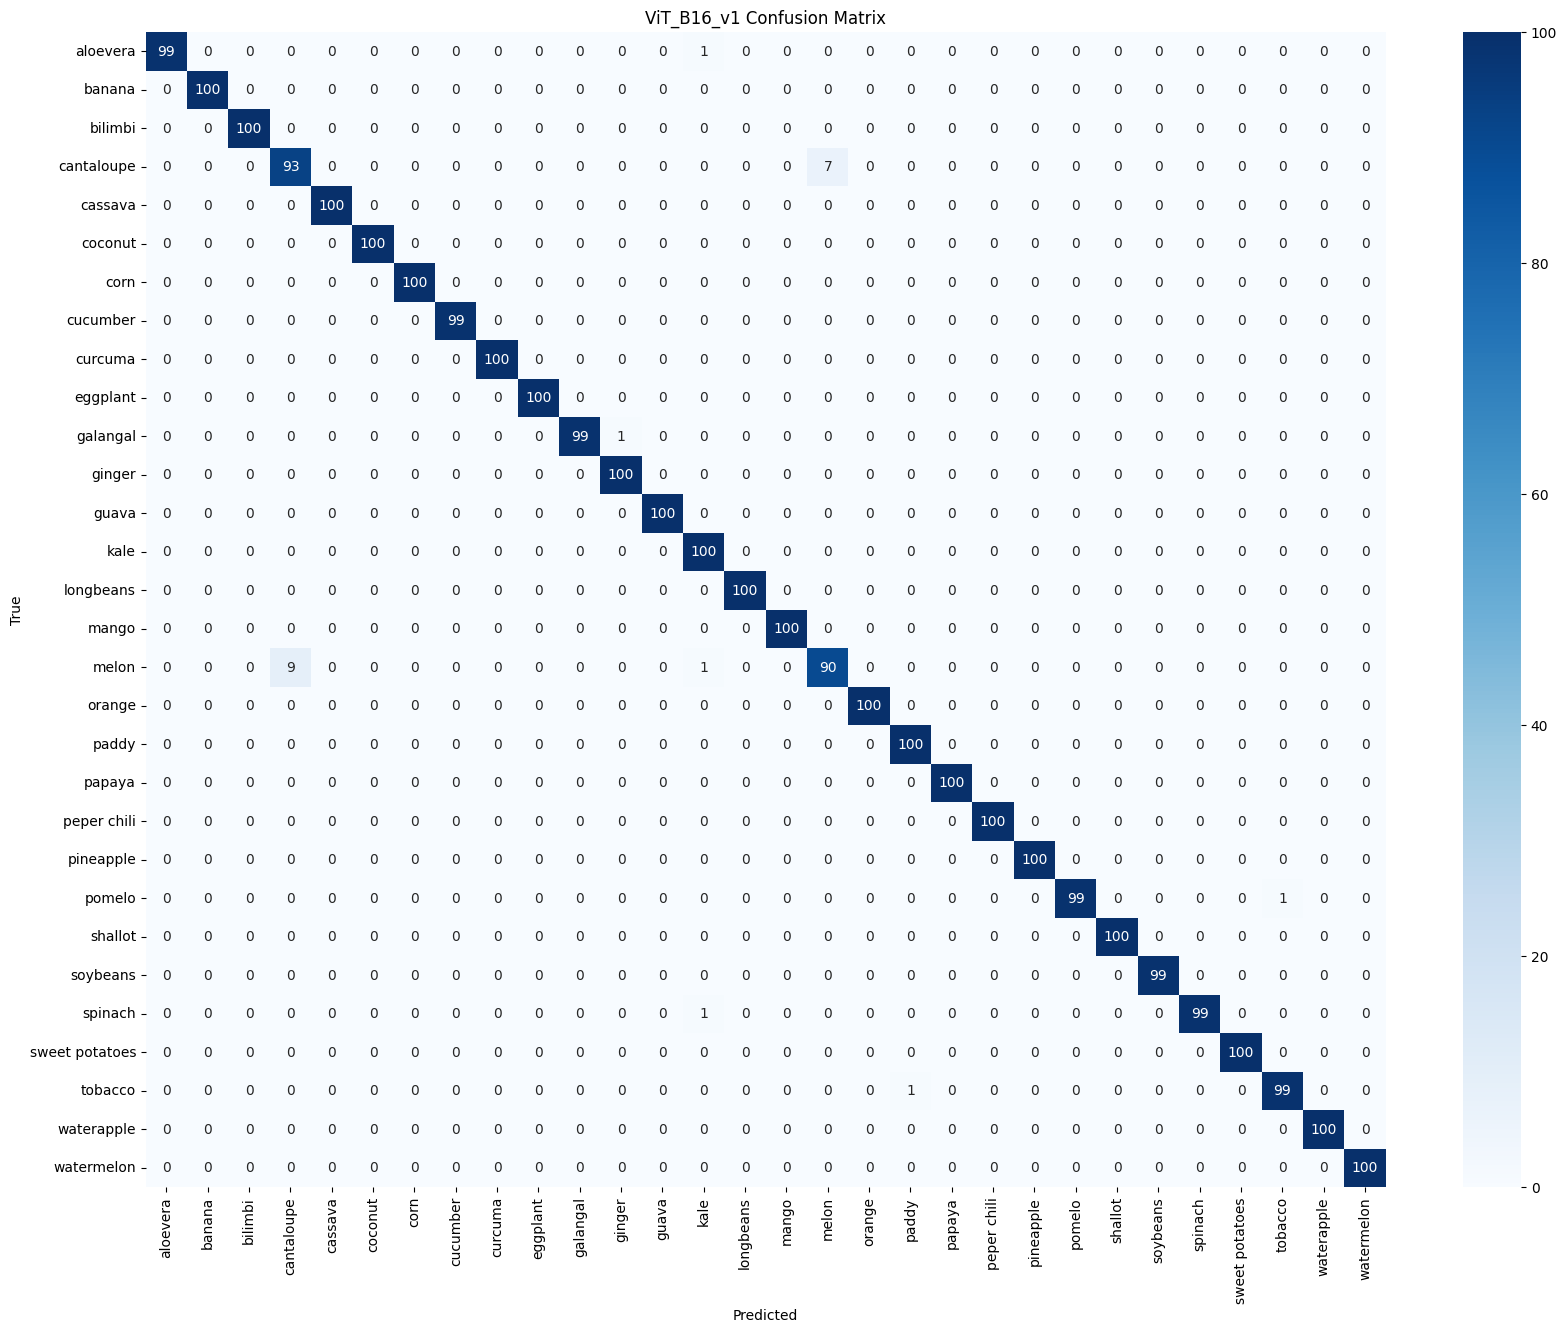

In [ ]:
# --- 5. EVALUATION ---

# Start Testing
print(f"\nStarting {MODEL_NAME} model testing...")
# Load the best checkpoint for testing
test_results_finetune = trainer_finetune.test(
    finetune_lightning_model,
    test_dataloader,
    ckpt_path='best' # Automatically uses the best checkpoint
)
print(f"{MODEL_NAME} Test Results:", test_results_finetune)

model_name = "ViT_B16_v1" # Set the model name for this evaluation

print(f"\n--- Detailed {model_name} Evaluation ---")

# Get the main test results from the trainer
overall_metrics = test_results_finetune[0]

# Get all predictions and labels
all_preds = torch.cat(finetune_lightning_model.test_preds)
all_labels = torch.cat(finetune_lightning_model.test_labels)

# --- Classification Report ---
# Get string report for printing
report_str = classification_report(
    all_labels.numpy(),
    all_preds.numpy(),
    target_names=class_names,
    digits=3
)
print("Classification Report:")
print(report_str)

# --- Get dictionary report for saving ---
report_dict = classification_report(
    all_labels.numpy(),
    all_preds.numpy(),
    target_names=class_names,
    output_dict=True
)

# --- Confusion Matrix ---
confmat = finetune_lightning_model.test_confmat.compute().cpu().numpy()
df_cm = pd.DataFrame(
    confmat,
    index=[name for name in class_names],
    columns=[name for name in class_names]
)

plt.figure(figsize=(20, 15))
sn.heatmap(df_cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"{model_name} Confusion Matrix") # Use the model name in title
plt.savefig(f"{model_name}_confusion_matrix.png") # Use model name in filename
print(f"Confusion matrix plot saved to {model_name}_confusion_matrix.png")


# --- 6. SAVE RESULTS FOR COMPARISON ---

print(f"\n💾 Saving results for model: {model_name}...")

# Combine all results into one dictionary for this model
final_model_results = {
    "overall_metrics": overall_metrics,
    "classification_report": report_dict
}

# Define the file to store all model comparisons
results_file = "model_comparison_results.json"

# Load existing results if the file exists, or create a new dict
try:
    with open(results_file, 'r') as f:
        all_model_results = json.load(f)
except FileNotFoundError:
    all_model_results = {}

# Add or update the results for the current model
all_model_results[model_name] = final_model_results

# Save the updated results back to the file
with open(results_file, 'w') as f:
    json.dump(all_model_results, f, indent=4)

print(f"✅ Results successfully saved to {results_file}")

Loaded 3 model results from model_comparison_results.json

--- Overall Model Performance ---
                      test_acc   test_f1  test_precision  test_recall
model_name                                                           
ResNet18_FineTune_v1  0.980654  0.734340        0.738769     0.730369
EfficientNet_B0_v1    0.991661  0.897959        0.900378     0.895823
ViT_B16_v1            0.992662  0.922376        0.925086     0.919940
Saved 'comparison_overall_metrics.png'

--- Average F1-Score Performance ---
class_name            macro avg  weighted avg
model_name                                   
EfficientNet_B0_v1     0.991612      0.991607
ResNet18_FineTune_v1   0.980583      0.980577
ViT_B16_v1             0.992656      0.992651
Saved 'comparison_average_f1_scores.png'

--- Performance for Specific Class: 'Banana' ---
Available classes are: ['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant', 'galangal', 'ginger', '

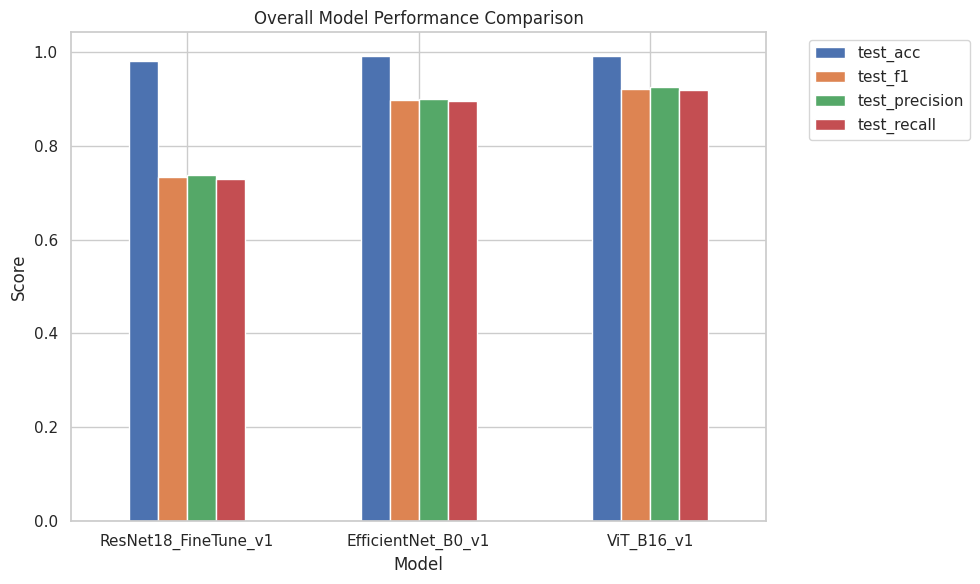

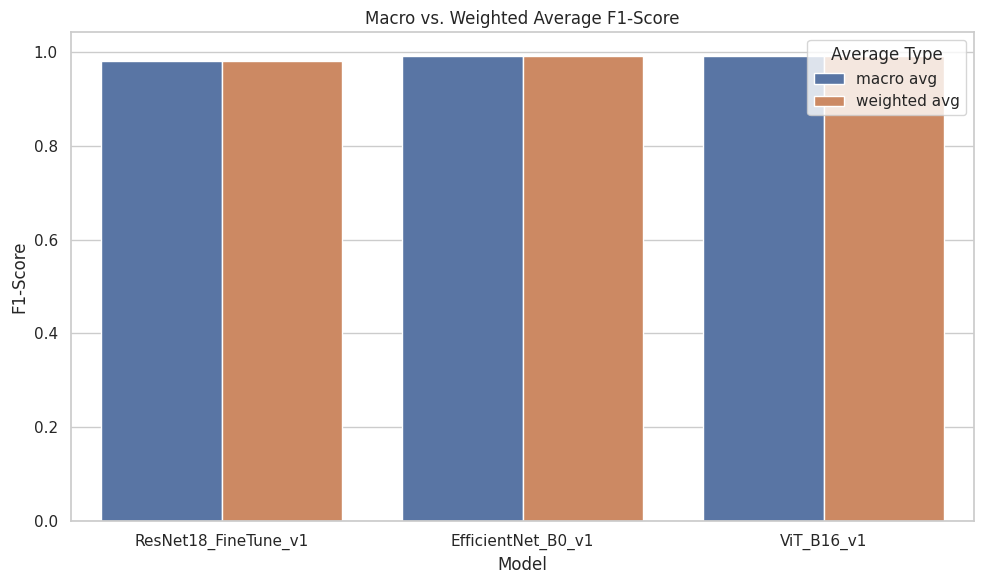

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# --- CONFIGURATION ---

# The file where your results are saved
RESULTS_FILE = "model_comparison_results.json"

# The specific class you want to compare (must match a name in your report)
# Change this to any class you're interested in!
CLASS_TO_COMPARE = "Banana"

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# --- 1. LOAD AND PROCESS DATA ---

try:
    with open(RESULTS_FILE, 'r') as f:
        all_results = json.load(f)
except FileNotFoundError:
    print(f"Error: Results file not found at {RESULTS_FILE}")
    print("Please run your model training scripts first.")
    sys.exit(1)
except json.JSONDecodeError:
    print(f"Error: Could not read {RESULTS_FILE}. File might be empty or corrupt.")
    sys.exit(1)

print(f"Loaded {len(all_results)} model results from {RESULTS_FILE}")

# We will create two DataFrames:
# 1. df_overall: For overall metrics (test_acc, test_f1, etc.)
# 2. df_report: For all per-class metrics from the classification report

overall_list = []
per_class_list = []

all_class_names = set()

for model_name, data in all_results.items():

    # 1. Process overall metrics
    overall_metrics = data.get('overall_metrics', {})
    overall_metrics['model_name'] = model_name
    overall_list.append(overall_metrics)

    # 2. Process classification report
    report = data.get('classification_report', {})
    for class_or_avg, metrics in report.items():
        if isinstance(metrics, dict): # Check if it's a class/avg entry
            metrics_data = metrics.copy()
            metrics_data['model_name'] = model_name
            metrics_data['class_name'] = class_or_avg
            per_class_list.append(metrics_data)

            # Store class names, but ignore averages
            if class_or_avg not in ['accuracy', 'macro avg', 'weighted avg']:
                all_class_names.add(class_or_avg)

# Create the DataFrames
df_overall = pd.DataFrame(overall_list).set_index('model_name')
df_report = pd.DataFrame(per_class_list)

# --- 2. PLOT 1: OVERALL METRIC COMPARISON ---

print("\n--- Overall Model Performance ---")
# Select the most important metrics
metrics_to_plot = ['test_acc', 'test_f1', 'test_precision', 'test_recall']
# Filter to only columns that exist
metrics_to_plot = [col for col in metrics_to_plot if col in df_overall.columns]

if not metrics_to_plot:
    print("Could not find overall metrics (test_acc, test_f1) to plot.")
else:
    print(df_overall[metrics_to_plot])

    plt.figure(figsize=(10, 6))
    df_overall[metrics_to_plot].plot(
        kind='bar',
        ax=plt.gca(), # Use the current axes
        rot=0, # Keep model names horizontal
        title="Overall Model Performance Comparison"
    )
    plt.ylabel("Score")
    plt.xlabel("Model")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
    plt.tight_layout()
    plt.savefig("comparison_overall_metrics.png")
    print("Saved 'comparison_overall_metrics.png'")


# --- 3. PLOT 2: MACRO VS. WEIGHTED AVERAGE F1-SCORE ---

print("\n--- Average F1-Score Performance ---")
df_averages = df_report[df_report['class_name'].isin(['macro avg', 'weighted avg'])]

if df_averages.empty:
    print("Could not find 'macro avg' or 'weighted avg' in results.")
else:
    # Print the data for clarity
    print(df_averages.pivot(index='model_name', columns='class_name', values='f1-score'))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_averages,
        x='model_name',
        y='f1-score',
        hue='class_name' # Group by 'macro avg' vs 'weighted avg'
    )
    plt.title("Macro vs. Weighted Average F1-Score")
    plt.ylabel("F1-Score")
    plt.xlabel("Model")
    plt.legend(title="Average Type")
    plt.tight_layout()
    plt.savefig("comparison_average_f1_scores.png")
    print("Saved 'comparison_average_f1_scores.png'")


# --- 4. PLOT 3: SPECIFIC CLASS F1-SCORE ---

print(f"\n--- Performance for Specific Class: '{CLASS_TO_COMPARE}' ---")

# Check if the class exists in our data
if CLASS_TO_COMPARE not in all_class_names:
    print(f"Warning: Class '{CLASS_TO_COMPARE}' not found in results.")
    print("Available classes are:", list(sorted(all_class_names)))
else:
    df_specific = df_report[df_report['class_name'] == CLASS_TO_COMPARE]

    if df_specific.empty:
        print(f"No data found for class '{CLASS_TO_COMPARE}'.")
    else:
        print(df_specific.set_index('model_name')[['f1-score', 'precision', 'recall']])

        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=df_specific,
            x='model_name',
            y='f1-score',
            palette='Blues_d' # Use a single-color palette
        )
        plt.title(f"F1-Score Comparison for '{CLASS_TO_COMPARE}'")
        plt.ylabel("F1-Score")
        plt.xlabel("Model")
        plt.tight_layout()
        plt.savefig(f"comparison_{CLASS_TO_COMPARE}_f1_score.png")
        print(f"Saved 'comparison_{CLASS_TO_COMPARE}_f1_score.png'")


print("\nAll plots generated. Displaying...")
# Show all plots at the end
plt.show()